**1. Load the dataset:**

In [15]:
import pandas as pd

# Load the dataset
file_path = '/content/weather_data.csv.crdownload'
data = pd.read_csv(file_path)

# Display the first few rows
data.head()


,date,temperature
0,2014-01-01,10.248357
1,2014-01-02,9.950428
2,2014-01-03,10.362958
3,2014-01-04,10.820167
4,2014-01-05,9.961091


**2. Preprocess the data:**

In [16]:
import pandas as pd


data['date'] = pd.to_datetime(data['date'], errors='coerce')

data = data.dropna(subset=['date'])

data = data.reset_index(drop=True)




In [17]:
# Normalize the temperature data
scaler = MinMaxScaler()
data['temperature_normalized'] = scaler.fit_transform(data[['temperature']])

In [18]:
# Split the dataset into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)

**Build an LSTM Autoencoder:**

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector


sequence_length = 20

model = Sequential([
    LSTM(64, activation='relu', input_shape=(sequence_length, 1), return_sequences=True),
     # Encoder: reduces dimensions to a latent representation
    LSTM(32, activation='relu', return_sequences=False),
     # Repeats the latent representation for decoding
    RepeatVector(sequence_length),
    LSTM(32, activation='relu', return_sequences=True),
    LSTM(64, activation='relu', return_sequences=True),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 20, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_1 (RepeatVector)       │ (None, 20, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 20, 32)              │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 20, 64)              │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20, 1)               │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,529 (244.25 KB)

 Trainable params: 62,529 (244.25 KB)

 Non-trainable params: 0 (0.00 B)

**Train the model:**

**Sequence Creation Step**

In [20]:
import numpy as np

def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length):
        seq = data[i : i + sequence_length]
        sequences.append(seq)
    return np.array(sequences)

sequence_length = 30

train_sequences = create_sequences(train_data['temperature_normalized'].values, sequence_length)
test_sequences = create_sequences(test_data['temperature_normalized'].values, sequence_length)

X_train = train_sequences.reshape((train_sequences.shape[0], train_sequences.shape[1], 1))
X_test = test_sequences.reshape((test_sequences.shape[0], test_sequences.shape[1], 1))


In [22]:
model.compile(optimizer='adam', loss='mse')


**Training**

In [25]:
from tensorflow.keras.layers import LSTM, Dense, RepeatVector

model = Sequential([
    LSTM(64, activation='relu', input_shape=(sequence_length, 1), return_sequences=True),
    LSTM(32, activation='relu', return_sequences=False),
    RepeatVector(sequence_length),
    LSTM(32, activation='relu', return_sequences=True),
    LSTM(64, activation='relu', return_sequences=True),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, X_test),
    shuffle=False
)

loss = model.evaluate(X_test, X_test)
print(f"Test Reconstruction Error (Loss): {loss}")


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.2434 - val_loss: 0.0471
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0437 - val_loss: 0.0320
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0281 - val_loss: 0.0211
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0187 - val_loss: 0.0160
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 0.0137 - val_loss: 0.0113
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0089 - val_loss: 0.1178
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0275 - val_loss: 0.0120
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0088 - val_loss: 0.0080
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0059 - val_loss: 0.0054
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0032 - val_loss: 0.0040
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0021 - val_loss: 0.0038
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0020 - val_

**Anomaly Detection:**

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Anomaly Dates:
[]


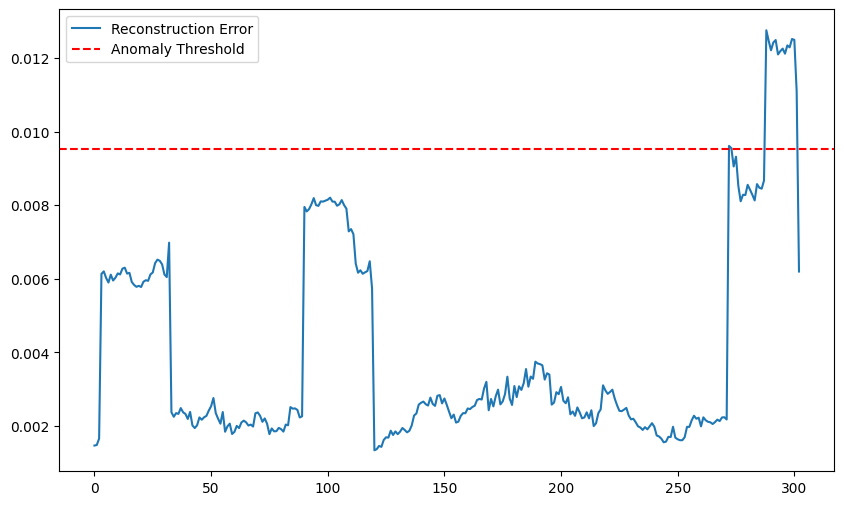

In [33]:
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(X_test)

reconstruction_error = np.mean(np.square(X_test - predictions), axis=1)

threshold = np.percentile(reconstruction_error, 95)

anomalies = reconstruction_error > threshold


anomaly_dates = test_data['date'].iloc[sequence_length:len(test_data['date']) - sequence_length +1 ].values
anomaly_dates = anomaly_dates[anomalies[:len(anomaly_dates)].flatten()]  # Adjust indexing


print("Anomaly Dates:")
print(anomaly_dates)

plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')
plt.legend()
plt.show()

**Visualize the Results**


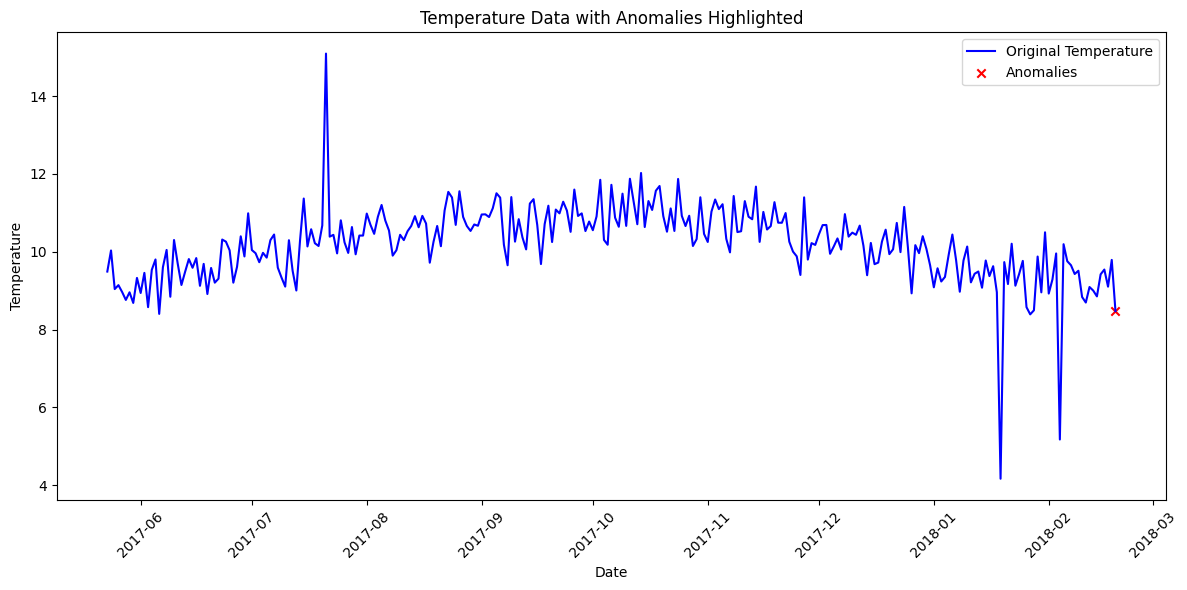

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(test_data['date'].iloc[sequence_length:], test_data['temperature'].iloc[sequence_length:], label='Original Temperature', color='blue')


anomalous_temperatures = test_data['temperature'].iloc[sequence_length:][anomalies[:len(test_data) - sequence_length].flatten()].values


anomaly_dates = test_data['date'].iloc[sequence_length:][anomalies[:len(test_data) - sequence_length].flatten()].values

plt.scatter(anomaly_dates, anomalous_temperatures, color='red', label='Anomalies', marker='x')

plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Temperature Data with Anomalies Highlighted')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

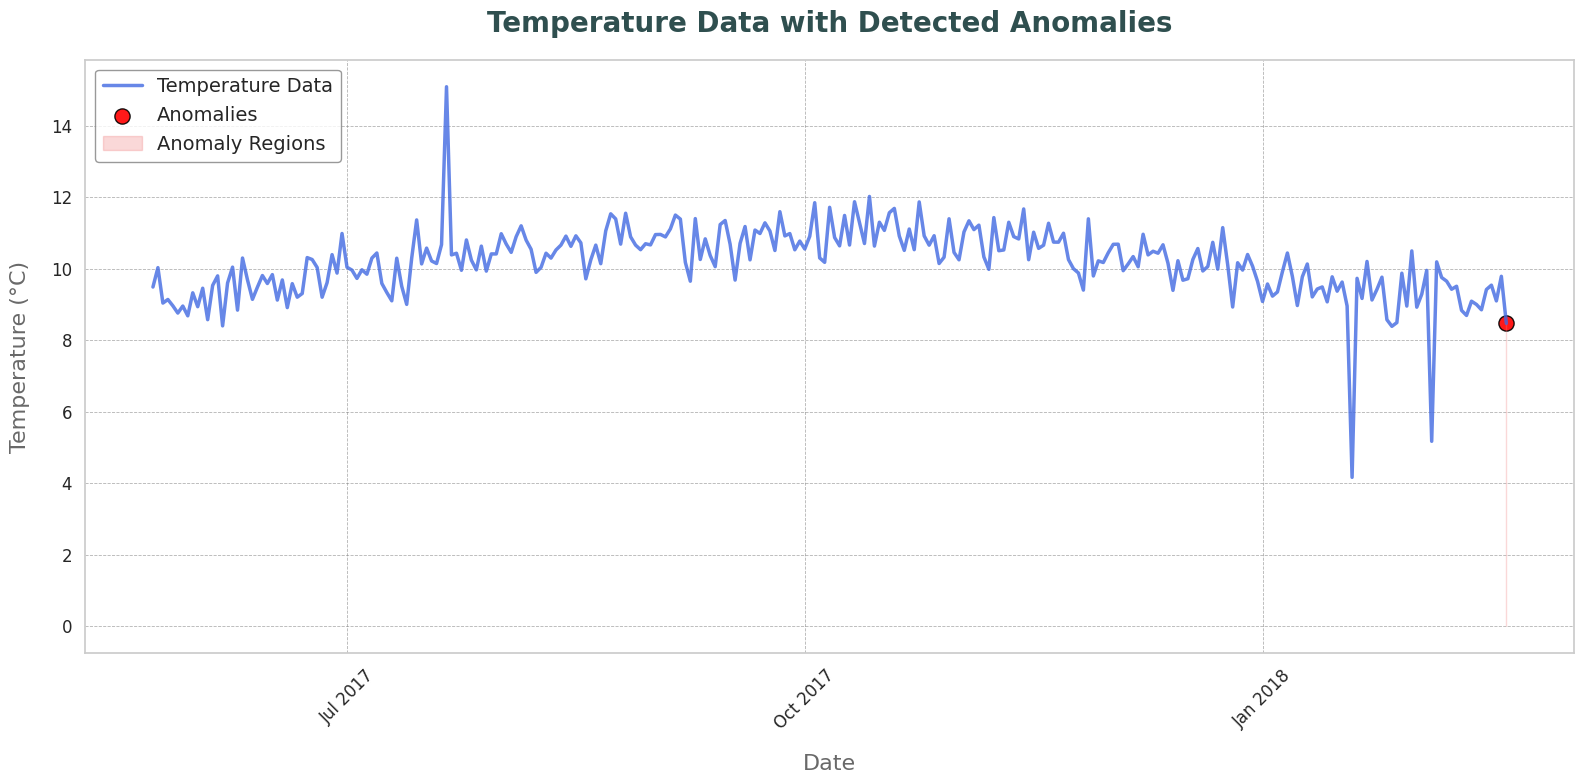

In [40]:
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 8))

plt.plot(
    test_data['date'].iloc[sequence_length:],
    test_data['temperature'].iloc[sequence_length:],
    label='Temperature Data',
    color='royalblue',
    linewidth=2.5,
    alpha=0.8
)

anomalous_temperatures = test_data['temperature'].iloc[sequence_length:][anomalies[:len(test_data) - sequence_length].flatten()].values
anomaly_dates = test_data['date'].iloc[sequence_length:][anomalies[:len(test_data) - sequence_length].flatten()].values

plt.scatter(
    anomaly_dates,
    anomalous_temperatures,
    color='red',
    label='Anomalies',
    marker='o',
    edgecolor='black',
    s=120,
    alpha=0.9
)

plt.fill_between(
    test_data['date'].iloc[sequence_length:],
    test_data['temperature'].iloc[sequence_length:],
    where=anomalies[:len(test_data) - sequence_length].flatten(),
    color='lightcoral',
    alpha=0.3,
    label='Anomaly Regions'
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.title('Temperature Data with Detected Anomalies', fontsize=20, pad=20, fontweight='bold', color='darkslategray')
plt.xlabel('Date', fontsize=16, labelpad=15, color='dimgray')
plt.ylabel('Temperature (°C)', fontsize=16, labelpad=15, color='dimgray')
plt.legend(fontsize=14, loc='upper left', frameon=True, facecolor='white', edgecolor='gray')

plt.grid(color='gray', linestyle='--', linewidth=0.6, alpha=0.6)

plt.tight_layout()

plt.show()


**Interpration**

 # Model Architecture:

- An LSTM autoencoder is used, which is appropriate for sequential data and anomaly detection.

- The encoder compresses the input sequence into a lower-dimensional representation, and the decoder reconstructs the original sequence. Anomalies lead to larger reconstruction errors.

# 4. Model Training and Evaluation:

- The model is compiled with the 'adam' optimizer and 'mse' loss function.

- The training uses the training data to learn the patterns of normal temperature variations.

- The validation data is used to monitor the model's performance on unseen data during training.

- The `evaluate()` function provides the test reconstruction error, which can give a sense of how well the model reconstructs data.

# 5. Anomaly Detection:
-The model is used to reconstruct the test sequences.

- The reconstruction error is calculated as the mean squared error between the original and reconstructed sequences.

- Anomalies are detected by setting a threshold based on the 95th percentile of the reconstruction error distribution. Points with errors higher than the threshold are classified as anomalies.

